### Zmiany w FACTM dodające wsparcie dla kohort
Poniżej lista modyfikacji w kodzie i krótkie wyjaśnienia, gdzie patrzeć oraz jak to używać.

- Dodano pola w FAParams: `cohort_labels`, `cohort_mu`, `cohort_sigma2`.
- Inicjalizacja: w `FA.__init__` (przyjmowanym `starting_params_fa`) jeśli podano `cohort_labels` (tablica długości N):
  - jeśli brak `cohort_mu`, inicjalizowane jest `cohort_mu` ~ Normal(0,1) (shape C x K).
  - jeśli brak `cohort_sigma2`, inicjalizowane jest jako macierz jedynek (C x K).
- Estymacja: dodano `FA.update_cohort_params()` — proste estymaty momentowe:
  `mu_c = mean_n E[z_n]` dla próbki n w kohorcie c;
  `sigma2_c = mean_n (Var[z_n] + (E[z_n]-mu_c)^2)`.
  Metoda jest wywoływana w `FA.update()` przed aktualizacją z (M-step-like).
- Aktualizacja Z: w `src/z_priors/StdNormal.py` aktualizacja `vi_mu/vi_var` wykorzystuje teraz prior N(mu_c, diag(sigma2_c)) (jeśli `cohort_labels` jest ustawione).
- ELBO: metoda `ELBO` dla węzła Z (`StdNormalZPrior.ELBO`) została rozszerzona o oczekiwany log-prior kohortowy NAGRODA, więc `get_elbo()` powinno teraz odzwierciedlać wpływ priorytetu.
- Interfejs: `FACTModel` przyjmuje teraz opcjonalne argumenty `starting_params_fa` i `starting_params_ctm`; do FA można przekazać `starting_params_fa={"cohort_labels": labels, ...}`.

Uwaga: obecna implementacja estymuje `cohort_mu` i `cohort_sigma2` przy użyciu wariacyjnego Bayesa (VB) z koniugatnym Normal–Inverse‑Gamma hiperpriorem.
- Hiperpriory: mu_ck | sigma2_ck ~ N(mu0_k, sigma2_ck / kappa0); sigma2_ck ~ InvGamma(alpha0, beta0)
- Posterior (VB) parametry: kappa_n = kappa0 + n_c; mu_n = (kappa0*mu0 + n_c * mean_Ez) / kappa_n; alpha_n = alpha0 + n_c/2; beta_n = beta0 + 0.5 * sum_n (E[z^2]_n - 2*E[z]_n*mean_Ez + mean_Ez^2) + 0.5*(kappa0*n_c)/kappa_n*(mean_Ez-mu0)^2
- Wartości używane w modelu: E[sigma2_ck] = beta_n / (alpha_n - 1) (dla alpha_n>1); E[mu_ck] = mu_n
Domyślne wartości hiperparametrów: mu0=0, kappa0=1, alpha0=2, beta0=1. Możesz przekazać inne wartości przez `starting_params_fa` (np. `hyper_kappa0`).
Te zmiany zostały dodane do `FA.update_cohort_params()` i zastępują poprzednie momentowe estymaty.

Jak użyć: wstaw `starting_params_fa = {"cohort_labels": cohort_labels_array}` przy tworzeniu modelu lub podaj też `cohort_mu`/`cohort_sigma2`.

Poniżej komórki ładujące dane, przygotowujące widoki i porównujące baseline (bez kohort) z modelem kohortowym.


In [1]:
# Imports and optional reload (restart kernel if modules changed)
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload

from src.views import Views
from src.build_model import FACTModel
from src.model_config import ModelConfig, SimpleViewConfig, StructuredViewConfig, SVIConfig
from src.enums import Likelihood, WPrior, ZPrior


In [2]:
df = pd.read_csv("data/raw_data_cohort.csv")

In [3]:
df.head()

,view,group,feature,sample,value
0,DNA,BC1,feature0_view0,IMMU-BC1-0164-FIXT-01,0.0
1,DNA,BC1,feature1_view0,IMMU-BC1-0164-FIXT-01,0.0
2,DNA,BC1,feature2_view0,IMMU-BC1-0164-FIXT-01,0.0
3,DNA,BC1,feature3_view0,IMMU-BC1-0164-FIXT-01,0.0
4,DNA,BC1,feature4_view0,IMMU-BC1-0164-FIXT-01,0.0


In [4]:
# Load long-format CSV and build per-view matrices
# Extract view index from feature name if present (e.g., feature0_view0)
df['view_idx'] = df['feature'].str.extract(r'_view(\d+)$').astype(float)
# If no view suffix, fall back to view_group unique mapping
if df['view_idx'].isna().all():
    grp_map = {g:i for i,g in enumerate(df['view_group'].unique())}
    df['view_idx'] = df['view_group'].map(grp_map)
df['view_idx'] = df['view_idx'].astype(int)
df['feature_base'] = df['feature'].str.replace(r'_view\d+$','', regex=True)

# Ensure sample order consistent
samples = sorted(df['sample'].unique())

In [5]:
samples

['IMMU-BC1-0164-FIXT-01',
 'IMMU-BC1-0191-FIXT-03',
 'IMMU-BC1-0213-FIXT-01',
 'IMMU-BC1-0248-FIXT-01',
 'IMMU-BC1-0297-FIXT-01',
 'IMMU-BC1-0297-FIXT-02',
 'IMMU-BC1-0319-FIXT-01',
 'IMMU-BC1-0327-FIXT-01',
 'IMMU-BC1-0327-FIXT-02',
 'IMMU-BC1-0329-FIXT-01',
 'IMMU-BC1-0367-FIXT-02',
 'IMMU-BC1-0370-FIXT-01',
 'IMMU-BC1-0422-FIXT-01',
 'IMMU-BC1-0422-FIXT-02',
 'IMMU-BC1-0744-FIXT-01',
 'IMMU-BC1-0745-FIXT-01',
 'IMMU-BC1-0822-FIXT-01',
 'IMMU-BC1-0882-FIXT-01',
 'IMMU-BC1-0890-FIXT-01',
 'IMMU-BC1-1010-FIXT-01',
 'IMMU-BC1-1038-FIXT-01',
 'IMMU-BC1-1061-FIXT-01',
 'IMMU-BC1-1130-FIXT-01',
 'IMMU-BC1-1140-FIXT-01',
 'IMMU-BC1-1167-FIXT-01',
 'IMMU-BC1-1175-FIXT-01',
 'IMMU-BC1-1302-FIXT-01',
 'IMMU-BC1-1326-FIXT-01',
 'IMMU-BC1-1363-FIXT-01',
 'IMMU-BC1-1731-FIXT-01',
 'IMMU-BC1-1732-FIXT-02',
 'IMMU-BC1-1761-FIXT-01',
 'IMMU-BC1-2017-FIXT-01',
 'IMMU-BC1-2020-FIXT-01',
 'IMMU-BC1-2042-FIXT-01',
 'IMMU-BC1-2156-FIXT-01',
 'IMMU-BC1-2212-FIXT-01',
 'IMMU-BC1-2234-FIXT-01',
 'IMMU-BC1-2

In [6]:
# Load long-format CSV and build per-view matrices
# Extract view index from feature name if present (e.g., feature0_view0)
df['view_idx'] = df['feature'].str.extract(r'_view(\d+)$').astype(float)
# If no view suffix, fall back to view_group unique mapping
if df['view_idx'].isna().all():
    grp_map = {g:i for i,g in enumerate(df['view_group'].unique())}
    df['view_idx'] = df['view_group'].map(grp_map)
df['view_idx'] = df['view_idx'].astype(int)
df['feature_base'] = df['feature'].str.replace(r'_view\d+$','', regex=True)

# Ensure sample order consistent
samples = sorted(df['sample'].unique())
num_views = df['view_idx'].max() + 1
views_list = []
for v in range(int(num_views)):
    sub = df[df['view_idx']==v]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index='sample', columns='feature_base', values='value', aggfunc='first')
    pivot = pivot.reindex(samples)  # align samples (NaN where missing)
    mat = pivot.to_numpy(dtype=float)
    views_list.append(mat)

views = Views.from_list(views_list)
print('Loaded', len(views_list), 'views, N=', views.N)

# Build cohort labels aligned to samples
group_series = df[['sample','group']].drop_duplicates().set_index('sample').reindex(samples)['group']
group_map = {g:i for i,g in enumerate(group_series.unique())}
cohort_labels = group_series.map(group_map).to_numpy(dtype=int)
print('Cohort map:', group_map)


Loaded 4 views, N= 1814
Cohort map: {'BC1': 0, 'BC2': 1, 'BC3': 2, 'NSCLC': 3, 'SCCHN1': 4, 'NSCLC2': 5, 'SCCHN3': 6}


In [7]:
cohort_counts = group_series.value_counts()
print(cohort_counts)

group
BC2       456
BC3       379
SCCHN1    262
SCCHN3    246
NSCLC     239
NSCLC2    191
BC1        41
Name: count, dtype: int64


In [ ]:
# Simple model config: all views as Normal simple views
K = 10
simple_cfgs = [SimpleViewConfig(Likelihood.NORMAL, WPrior.NONE) for _ in range(views.num_simple)]
structured_cfgs = []
z_priors = [ZPrior.STD_NORMAL] * K

# Enable SVI (same API as in run_factm_models.ipynb)
model_config = ModelConfig(
    simple_view_configs=simple_cfgs,
    structured_view_configs=structured_cfgs,
    z_priors=z_priors,
    node_update_factor=0.9,
    # svi=SVIConfig(
    #     enabled=True,
    #     batch_size=256,
    #     repeat_minibatch=True,
    #     rho_tau=0.5,
    #     rho_kappa=0.01,
    #     rho_power=0.75,
    #     rho_clip=(0.97, 1.0),
    #     warmup_iters=0,
    #     elbo_every=10,
    # )
)

print('K=', K, 'num_simple views=', views.num_simple)


K= 10 num_simple views= 4


In [9]:
# Baseline (no cohorts)
t0 = time.time()
model0 = FACTModel(views, K, model_config, seed=0)
model0.pretrain()
model0.fit(max_iter=100, pretrain=False)
print('Baseline time:', time.time()-t0)


Pretraining FA
Fitting model


100%|██████████| 100/100 [03:56<00:00,  2.36s/it]

Baseline time: 240.2391390800476


In [10]:
cohort_labels

array([0, 0, 0, ..., 6, 6, 6], shape=(1814,))

In [11]:
# With cohort prior (pass cohort_labels)
t1 = time.time()
starting_params_fa = {'cohort_labels': cohort_labels}
model1 = FACTModel(views, K, model_config, seed=0, starting_params_fa=starting_params_fa)
model1.pretrain()
model1.fit(max_iter=100, pretrain=False)
print('Cohort model time:', time.time()-t1)


Pretraining FA
Fitting model


100%|██████████| 100/100 [03:51<00:00,  2.31s/it]

Cohort model time: 234.3610680103302


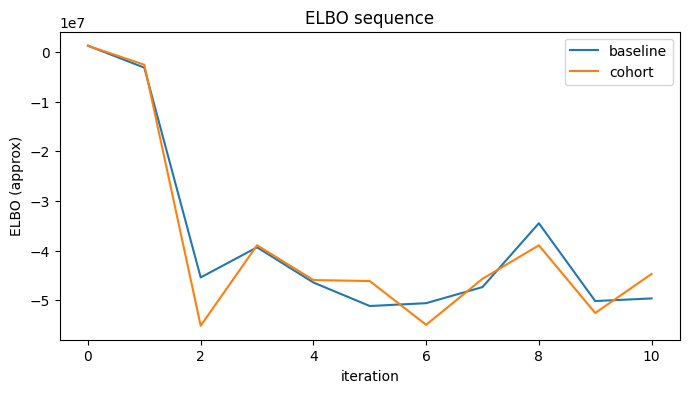

In [12]:
# Compare ELBO sequences
plt.figure(figsize=(8,4))
elbo0 = model0.elbo_sequence
elbo1 = model1.elbo_sequence
plt.plot(elbo0, label='baseline')
plt.plot(elbo1, label='cohort')
plt.xlabel('iteration')
plt.ylabel('ELBO (approx)')
plt.legend()
plt.title('ELBO sequence')
plt.show()

In [13]:
# Reconstruction MSE on view 0
if views.num_simple>0:
    y = views.simple[0].data
    r0 = model0.get_predictions_FA(0)
    r1 = model1.get_predictions_FA(0)
    mse0 = np.nanmean((y-r0)**2)
    mse1 = np.nanmean((y-r1)**2)
    print('Recon MSE view0 baseline:', mse0)
    print('Recon MSE view0 cohort:  ', mse1)

Recon MSE view0 baseline: 0.0044894302798193
Recon MSE view0 cohort:   0.004399128167793522


In [14]:
# Latent comparison: mean squared diff
Z0 = model0.get_latent_factors()
Z1 = model1.get_latent_factors()
print('mean squared diff Z:', np.mean((Z0-Z1)**2))

mean squared diff Z: 0.013487160228219143


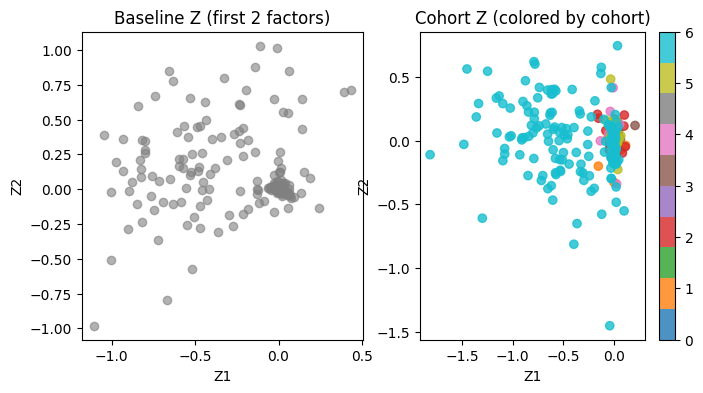

In [15]:
# Scatter first two factors colored by cohort (from cohort_labels)
if Z1.shape[1]>=2:
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title('Baseline Z (first 2 factors)')
    plt.scatter(Z0[:,0], Z0[:,1], c='gray', alpha=0.6)
    plt.xlabel('Z1'); plt.ylabel('Z2')
    plt.subplot(1,2,2)
    plt.title('Cohort Z (colored by cohort)')
    plt.scatter(Z1[:,0], Z1[:,1], c=cohort_labels, cmap='tab10', alpha=0.8)
    plt.xlabel('Z1'); plt.ylabel('Z2')
    plt.colorbar(); plt.show()

In [16]:
# Print estimated cohort params
if getattr(model1.fa.params, 'cohort_mu', None) is not None:
    print('Estimated cohort_mu:')
    print(model1.fa.params.cohort_mu)
    print('Estimated cohort_sigma2:')
    print(model1.fa.params.cohort_sigma2)

Estimated cohort_mu:
[[-0.25180645 -0.11716737  0.05354942 -0.18783857 -0.18909504  0.20780602
  -0.01661629 -0.21924742  0.04210983  0.35100256]
 [-0.06847402  0.05945429 -0.01848055 -0.04763628 -0.07964398 -0.04248011
   0.02584433 -0.01814373  0.01319605  0.03580165]
 [ 0.06926947 -0.01258686 -0.06132792 -0.05215053 -0.03454213 -0.08181549
  -0.00993088 -0.05668447 -0.02999505  0.08935028]
 [ 0.03968613 -0.06541703 -0.03819964  0.03971856  0.10336924  0.00445053
   0.00125879 -0.01918614  0.01478221 -0.06128688]
 [-0.11800042 -0.02857392 -0.03310122 -0.14129123 -0.0746739  -0.01961196
   0.04463358  0.0887176   0.04904146 -0.11113731]
 [ 0.14672035 -0.05116856 -0.01212685 -0.00654541 -0.06593199  0.09221593
   0.10293106  0.08659146  0.07383521  0.04590791]
 [ 0.01669277  0.12136495  0.02244508  0.01787912  0.00597838 -0.00127524
  -0.0391022   0.03686065 -0.09453266  0.12932305]]
Estimated cohort_sigma2:
[[1.8436178  1.97597981 1.8537723  1.75152394 2.00195485 1.87295176
  1.722286

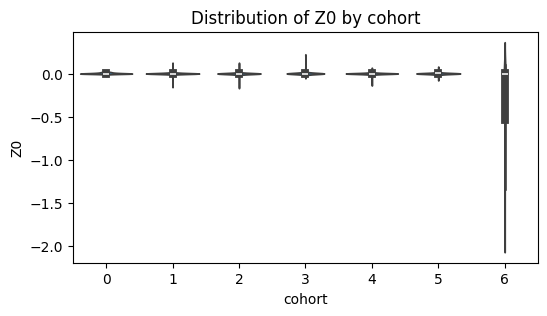

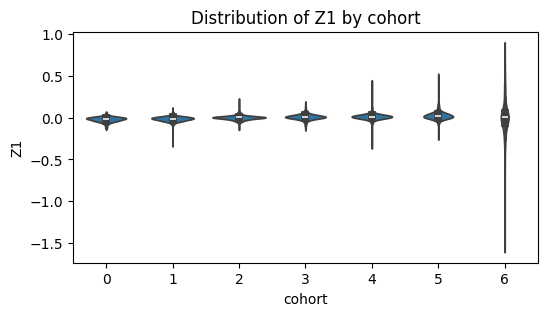

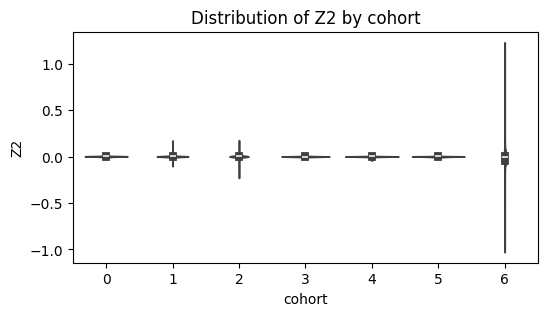

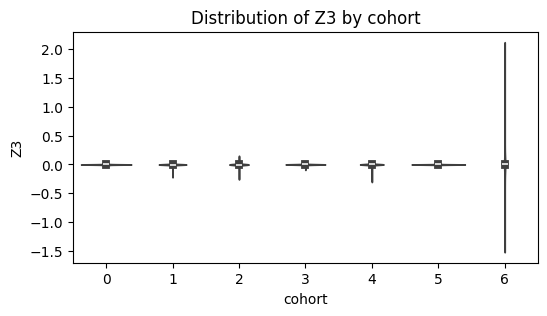

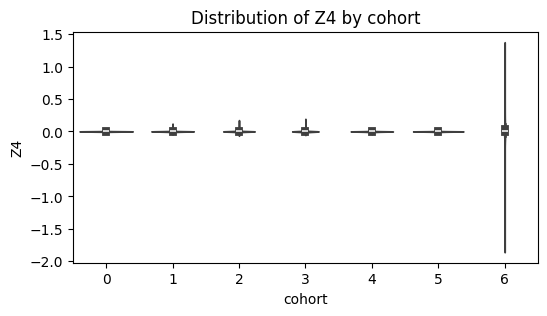

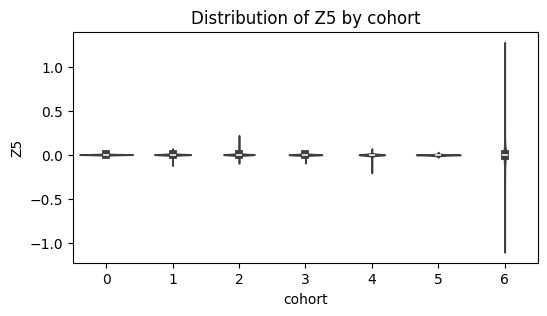

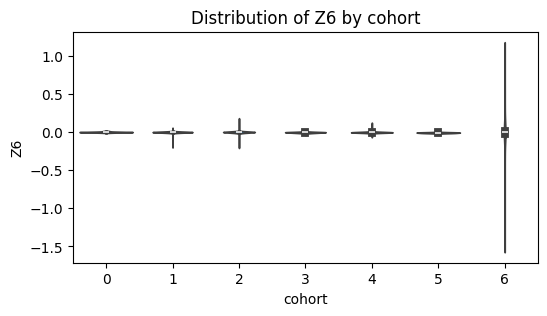

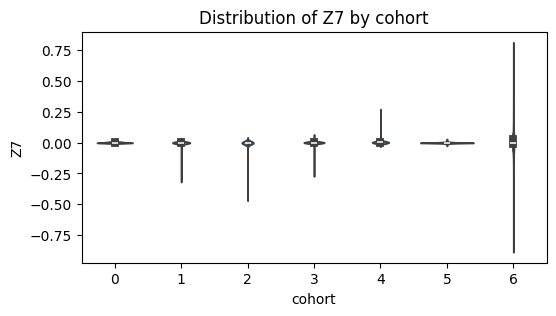

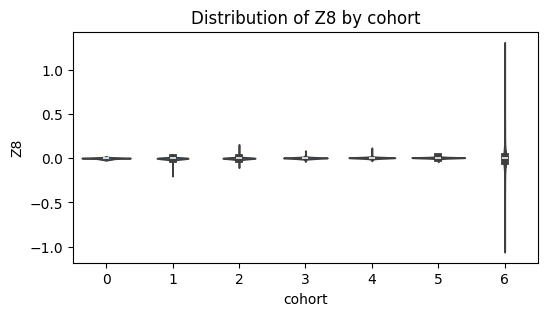

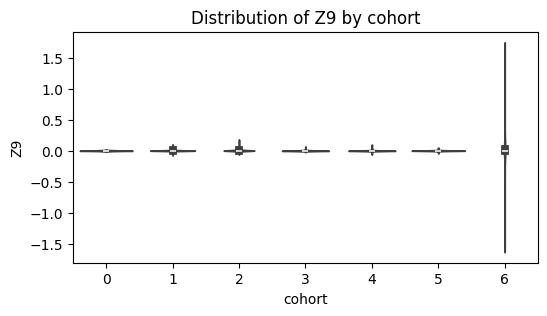

In [17]:
import pandas as pd
Z = model1.get_latent_factors()
dfZ = pd.DataFrame(Z[:, :10], columns=[f"Z{k}" for k in range(10)])
dfZ['cohort'] = cohort_labels
for k in range(10):
    plt.figure(figsize=(6,3))
    sns.violinplot(x='cohort', y=f'Z{k}', data=dfZ)
    plt.title(f'Distribution of Z{k} by cohort')
    plt.show()
